In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torchvision.utils as vutils
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Cell 1 Execution Complete: Libraries imported successfully. Using device:", device)

Cell 1 Execution Complete: Libraries imported successfully. Using device: cuda


In [2]:
class CustomAnimeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = glob.glob(os.path.join(root_dir, '**', '*.jpg'), recursive=True) + \
                           glob.glob(os.path.join(root_dir, '**', '*.png'), recursive=True) + \
                           glob.glob(os.path.join(root_dir, '**', '*.jpeg'), recursive=True)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

dataset_path = "/kaggle/input/datasets/soumikrakshit/anime-faces/data"

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = CustomAnimeDataset(root_dir=dataset_path, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
print(f"Cell 2 Execution Complete: Dataset loaded. Total images found: {len(dataset)}")

Cell 2 Execution Complete: Dataset loaded. Total images found: 43102


In [8]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(100, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

class DiscriminatorCritic(nn.Module):
    def __init__(self, use_sigmoid=True):
        super(DiscriminatorCritic, self).__init__()
        
        # WGAN-GP ke liye BatchNorm ki jagah InstanceNorm use hota hai
        norm_layer = nn.InstanceNorm2d if not use_sigmoid else nn.BatchNorm2d
        
        layers = [
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            norm_layer(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            norm_layer(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            norm_layer(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(512, 1, 4, 1, 0, bias=False)
        ]
        
        if use_sigmoid:
            layers.append(nn.Sigmoid())
            
        self.main = nn.Sequential(*layers)

    def forward(self, input):
        return self.main(input).view(-1)

print("Cell 3 Updated: Architecture now compatible with both DCGAN and WGAN-GP.")

Cell 3 Updated: Architecture now compatible with both DCGAN and WGAN-GP.


In [5]:
def save_checkpoint(state, filename):
    torch.save(state, filename)

def load_checkpoint(filename, netG, netD, optG, optD):
    if os.path.isfile(filename):
        checkpoint = torch.load(filename, map_location=device)
        netG.load_state_dict(checkpoint['netG'])
        netD.load_state_dict(checkpoint['netD'])
        optG.load_state_dict(checkpoint['optG'])
        optD.load_state_dict(checkpoint['optD'])
        return checkpoint['epoch']
    return 0

print("Cell 4 Execution Complete: Checkpoint saving and loading utilities are ready.")

Cell 4 Execution Complete: Checkpoint saving and loading utilities are ready.


In [6]:
netG_DC = Generator().to(device)
netD_DC = DiscriminatorCritic(use_sigmoid=True).to(device)
netG_DC.apply(weights_init)
netD_DC.apply(weights_init)

criterion = nn.BCELoss()
# Discriminator ka learning rate thoda kam kiya hai taaki wo zyada fast na seekhe
optimizerD_DC = optim.Adam(netD_DC.parameters(), lr=0.0001, betas=(0.5, 0.999)) 
optimizerG_DC = optim.Adam(netG_DC.parameters(), lr=0.0002, betas=(0.5, 0.999))

scaler_D = torch.amp.GradScaler('cuda')
scaler_G = torch.amp.GradScaler('cuda')

num_epochs = 50
start_epoch_dc = load_checkpoint("dcgan_checkpoint.pth", netG_DC, netD_DC, optimizerG_DC, optimizerD_DC)

G_losses_DC = []
D_losses_DC = []

print(f"Starting DCGAN Training from epoch {start_epoch_dc} to {num_epochs}...")

for epoch in range(start_epoch_dc, num_epochs):
    
    epoch_d_loss = 0.0
    epoch_g_loss = 0.0
    
    pbar = tqdm(enumerate(dataloader), total=len(dataloader), desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)
    
    for i, data in pbar:
        real_imgs = data.to(device)
        b_size = real_imgs.size(0)
        
        # LABEL SMOOTHING: 1.0 ki jagah 0.9 use kar rahe hain
        label = torch.full((b_size,), 0.9, dtype=torch.float, device=device)

        netD_DC.zero_grad()
        with torch.amp.autocast('cuda'):
            output = netD_DC(real_imgs)
        errD_real = criterion(output.float(), label)
        
        scaler_D.scale(errD_real).backward()
        
        # Fake labels ko 0.0 hi rakhenge (ya chaho toh 0.1 kar sakte ho)
        label.fill_(0.0)
        noise = torch.randn(b_size, 100, 1, 1, device=device)
        fake = netG_DC(noise)
        
        with torch.amp.autocast('cuda'):
            output = netD_DC(fake.detach())
        errD_fake = criterion(output.float(), label)
        
        scaler_D.scale(errD_fake).backward()
        errD = errD_real + errD_fake
        scaler_D.step(optimizerD_DC)
        scaler_D.update()

        netG_DC.zero_grad()
        # Generator ko trick karne ke liye wapas 1.0 set karenge
        label.fill_(1.0)
        with torch.amp.autocast('cuda'):
            output = netD_DC(fake)
        errG = criterion(output.float(), label)
        
        scaler_G.scale(errG).backward()
        scaler_G.step(optimizerG_DC)
        scaler_G.update()

        G_losses_DC.append(errG.item())
        D_losses_DC.append(errD.item())
        
        epoch_d_loss += errD.item()
        epoch_g_loss += errG.item()

        pbar.set_postfix({
            'D_Loss': f"{errD.item():.4f}", 
            'G_Loss': f"{errG.item():.4f}"
        })

    avg_d_loss = epoch_d_loss / len(dataloader)
    avg_g_loss = epoch_g_loss / len(dataloader)
    
    print(f"End of Epoch {epoch+1} | Avg D Loss: {avg_d_loss:.4f} | Avg G Loss: {avg_g_loss:.4f}")

    if (epoch + 1) % 5 == 0:
        save_checkpoint({
            'epoch': epoch + 1,
            'netG': netG_DC.state_dict(),
            'netD': netD_DC.state_dict(),
            'optG': optimizerG_DC.state_dict(),
            'optD': optimizerD_DC.state_dict()
        }, "dcgan_checkpoint.pth")

print("Cell 5 Execution Complete: DCGAN Training Finished.")

Starting DCGAN Training from epoch 0 to 50...


Epoch 1/50: 100%|██████████| 674/674 [02:50<00:00,  3.96it/s, D_Loss=7.7305, G_Loss=0.0141] 

End of Epoch 1 | Avg D Loss: 12.1228 | Avg G Loss: 0.1527



Epoch 2/50: 100%|██████████| 674/674 [00:45<00:00, 14.66it/s, D_Loss=2.2692, G_Loss=0.8500]

End of Epoch 2 | Avg D Loss: 5.6990 | Avg G Loss: 0.3061


...

End of Epoch 48 | Avg D Loss: 0.7709 | Avg G Loss: 2.6670



Epoch 49/50: 100%|██████████| 674/674 [00:40<00:00, 16.64it/s, D_Loss=0.6754, G_Loss=2.4126]

End of Epoch 49 | Avg D Loss: 0.7843 | Avg G Loss: 2.6254



Epoch 50/50: 100%|██████████| 674/674 [00:40<00:00, 16.60it/s, D_Loss=0.7313, G_Loss=2.0024]


End of Epoch 50 | Avg D Loss: 0.7925 | Avg G Loss: 2.5175
Cell 5 Execution Complete: DCGAN Training Finished.


In [10]:
netG_WGAN = Generator().to(device)
# use_sigmoid=False se BatchNorm ki jagah InstanceNorm use hoga (hamare naye Cell 3 logic se)
netD_WGAN = DiscriminatorCritic(use_sigmoid=False).to(device)

netG_WGAN.apply(weights_init)
netD_WGAN.apply(weights_init)

optimizerD_WGAN = optim.Adam(netD_WGAN.parameters(), lr=0.0001, betas=(0.0, 0.9))
optimizerG_WGAN = optim.Adam(netG_WGAN.parameters(), lr=0.0001, betas=(0.0, 0.9))

LAMBDA_GP = 10
CRITIC_ITERATIONS = 5

num_epochs = 50
start_epoch_wgan = load_checkpoint("/kaggle/working/wgangp_checkpoint.pth", netG_WGAN, netD_WGAN, optimizerG_WGAN, optimizerD_WGAN)

def compute_gradient_penalty(critic, real_samples, fake_samples, device):
    alpha = torch.rand((real_samples.size(0), 1, 1, 1), device=device)
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    d_interpolates = critic(interpolates)
    
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    
    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

print(f"Starting WGAN-GP Training from epoch {start_epoch_wgan} to {num_epochs}...")

for epoch in range(start_epoch_wgan, num_epochs):
    epoch_c_loss = 0.0
    epoch_g_loss = 0.0
    
    pbar = tqdm(enumerate(dataloader), total=len(dataloader), desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)
    
    for i, data in pbar:
        real_imgs = data.to(device)
        b_size = real_imgs.size(0)
        
        optimizerD_WGAN.zero_grad()
        noise = torch.randn(b_size, 100, 1, 1, device=device)
        fake_imgs = netG_WGAN(noise)
        
        critic_real = netD_WGAN(real_imgs).view(-1)
        critic_fake = netD_WGAN(fake_imgs.detach()).view(-1)
        
        gp = compute_gradient_penalty(netD_WGAN, real_imgs.data, fake_imgs.data, device)
        
        # WGAN Loss: E[D(fake)] - E[D(real)] + GP
        loss_critic = torch.mean(critic_fake) - torch.mean(critic_real) + LAMBDA_GP * gp
        
        loss_critic.backward()
        optimizerD_WGAN.step()
        
        loss_gen_val = 0.0
        if i % CRITIC_ITERATIONS == 0:
            optimizerG_WGAN.zero_grad()
            gen_fake = netD_WGAN(netG_WGAN(noise)).view(-1)
            loss_gen = -torch.mean(gen_fake)
            loss_gen.backward()
            optimizerG_WGAN.step()
            loss_gen_val = loss_gen.item()
            
        epoch_c_loss += loss_critic.item()
        epoch_g_loss += loss_gen_val
        
        pbar.set_postfix({
            'W_Loss': f"{loss_critic.item():.3f}", 
            'GP': f"{gp.item():.3f}",
            'G_Loss': f"{loss_gen_val:.3f}"
        })
        
    avg_c = epoch_c_loss / len(dataloader)
    avg_g = (epoch_g_loss * CRITIC_ITERATIONS) / len(dataloader)
    
    print(f"End of Epoch {epoch+1} | Avg Critic: {avg_c:.4f} | Avg Gen: {avg_g:.4f}")
    
    if (epoch + 1) % 5 == 0:
        save_checkpoint({
            'epoch': epoch + 1,
            'netG': netG_WGAN.state_dict(),
            'netD': netD_WGAN.state_dict(),
            'optG': optimizerG_WGAN.state_dict(),
            'optD': optimizerD_WGAN.state_dict()
        }, "/kaggle/working/wgangp_checkpoint.pth")

print("Cell 6 Execution Complete: WGAN-GP Training Finished.")

Starting WGAN-GP Training from epoch 0 to 50...


Epoch 1/50: 100%|██████████| 674/674 [01:16<00:00,  8.77it/s, W_Loss=-19.365, GP=0.411, G_Loss=0.000] 

End of Epoch 1 | Avg Critic: -9.2209 | Avg Gen: 8.6772



Epoch 2/50: 100%|██████████| 674/674 [01:16<00:00,  8.78it/s, W_Loss=-20.775, GP=0.488, G_Loss=0.000] 

End of Epoch 2 | Avg Critic: -18.7362 | Avg Gen: 19.7690


...

End of Epoch 48 | Avg Critic: -10.8143 | Avg Gen: 29.1884



Epoch 49/50: 100%|██████████| 674/674 [01:16<00:00,  8.79it/s, W_Loss=-11.081, GP=0.186, G_Loss=0.000] 

End of Epoch 49 | Avg Critic: -10.8027 | Avg Gen: 28.6121



Epoch 50/50: 100%|██████████| 674/674 [01:16<00:00,  8.79it/s, W_Loss=-11.230, GP=0.363, G_Loss=0.000] 


End of Epoch 50 | Avg Critic: -10.8055 | Avg Gen: 28.6673
Cell 6 Execution Complete: WGAN-GP Training Finished.


Generating final evaluation plots and sample images...


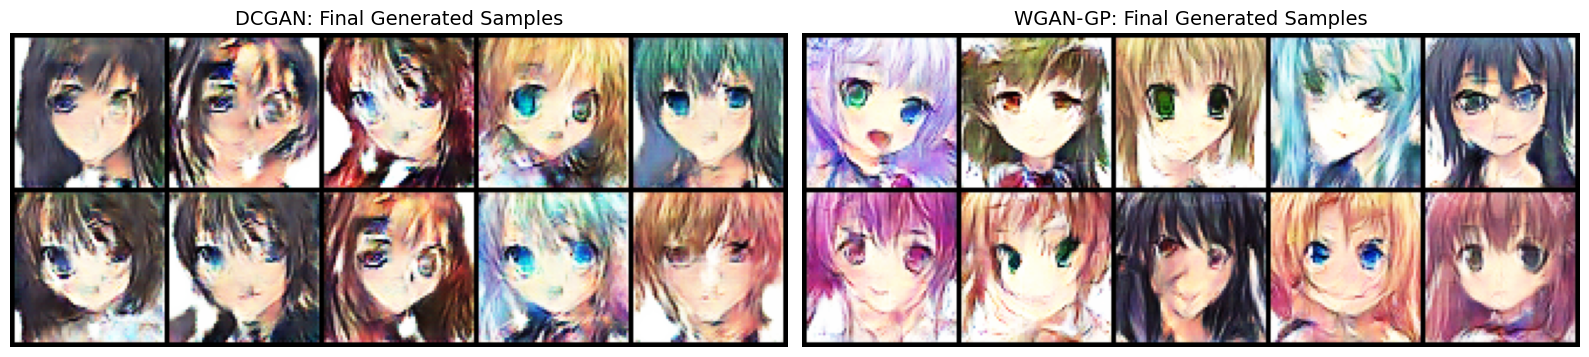

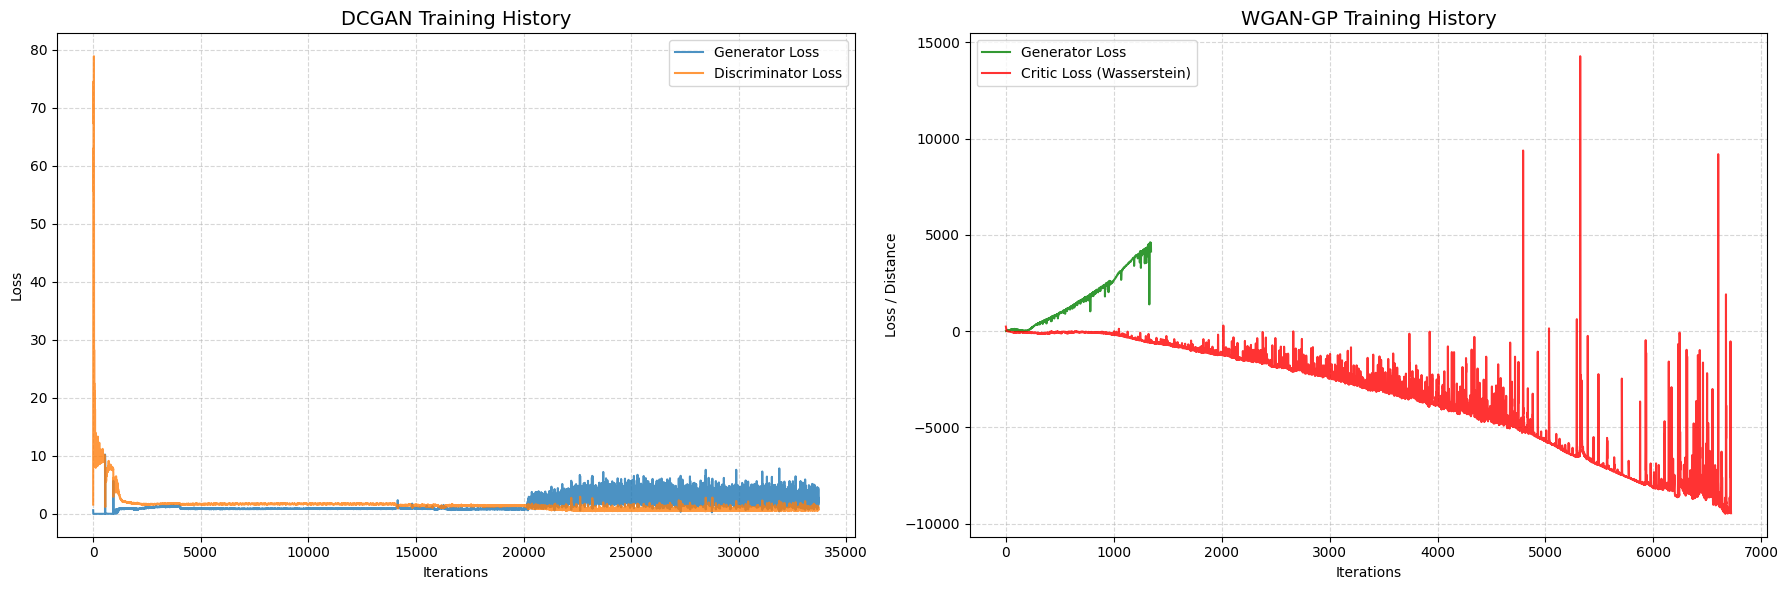

Cell 7 Execution Complete: DCGAN vs WGAN-GP Comparison Done.


In [11]:
print("Generating final evaluation plots and sample images...")

def show_comparison_results(netG_dc, netG_wgan, noise):
    netG_dc.eval()
    netG_wgan.eval()
    
    with torch.no_grad():
        fake_dc = netG_dc(noise).detach().cpu()
        fake_wgan = netG_wgan(noise).detach().cpu()

    plt.figure(figsize=(16, 8))
    
    # DCGAN Samples
    plt.subplot(1, 2, 1)
    plt.axis("off")
    plt.title("DCGAN: Final Generated Samples", fontsize=14)
    grid_dc = vutils.make_grid(fake_dc, nrow=5, padding=2, normalize=True)
    plt.imshow(np.transpose(grid_dc, (1, 2, 0)))

    # WGAN-GP Samples
    plt.subplot(1, 2, 2)
    plt.axis("off")
    plt.title("WGAN-GP: Final Generated Samples", fontsize=14)
    grid_wgan = vutils.make_grid(fake_wgan, nrow=5, padding=2, normalize=True)
    plt.imshow(np.transpose(grid_wgan, (1, 2, 0)))
    
    plt.tight_layout()
    plt.show()

# 10 samples generate karne ke liye noise
test_noise = torch.randn(10, 100, 1, 1, device=device)
show_comparison_results(netG_DC, netG_WGAN, test_noise)

# Loss Plotting
plt.figure(figsize=(18, 6))

# DCGAN Plot
plt.subplot(1, 2, 1)
plt.title("DCGAN Training History", fontsize=14)
plt.plot(G_losses_DC, label="Generator Loss", alpha=0.8)
plt.plot(D_losses_DC, label="Discriminator Loss", alpha=0.8)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# WGAN-GP Plot
plt.subplot(1, 2, 2)
plt.title("WGAN-GP Training History", fontsize=14)
plt.plot(G_losses_WGAN, label="Generator Loss", color='green', alpha=0.8)
plt.plot(D_losses_WGAN, label="Critic Loss (Wasserstein)", color='red', alpha=0.8)
plt.xlabel("Iterations")
plt.ylabel("Loss / Distance")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

print("Cell 7 Execution Complete: DCGAN vs WGAN-GP Comparison Done.")